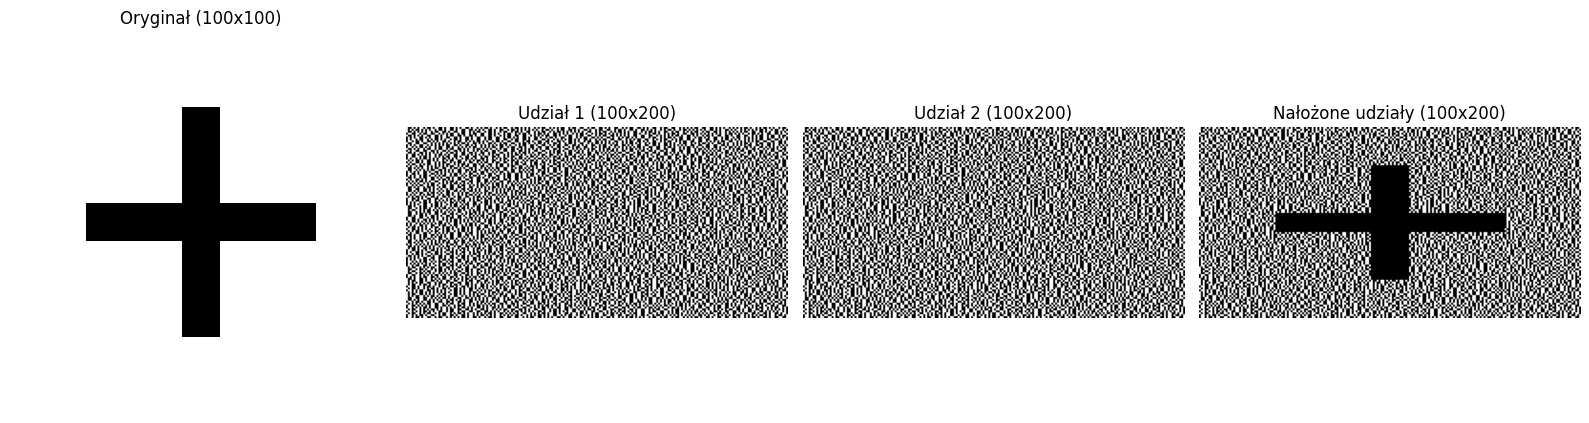

In [4]:
import numpy as np
import matplotlib.pyplot as plt

def create_test_image():
    """Generuje testowy obraz 100x100 pikseli (czarny krzyżyk na białym tle)."""

    img = np.zeros((100, 100), dtype=np.uint8)

    img[20:80, 45:55] = 1  
    img[45:55, 20:80] = 1 
    
    return img

def visual_cryptography_split(img):
    """
    Dzieli obraz na dwa udziały zastępując 1 piksel blokiem 1x2.
    Nie koryguje zniekształcenia formatu.
    """
    rows, cols = img.shape
   
    share1 = np.zeros((rows, cols * 2), dtype=np.uint8)
    share2 = np.zeros((rows, cols * 2), dtype=np.uint8)
    
    for i in range(rows):
        for j in range(cols):
            pixel = img[i, j]
            

            pattern = np.random.choice([0, 1])
            p1 = [1, 0] if pattern == 0 else [0, 1]
    
            share1[i, j*2 : j*2+2] = p1
            
            if pixel == 0:
     
                share2[i, j*2 : j*2+2] = p1
            else:

                share2[i, j*2 : j*2+2] = [1 - p1[0], 1 - p1[1]]
                
    return share1, share2

oryginal = create_test_image()

udzial1, udzial2 = visual_cryptography_split(oryginal)

zlozony = np.logical_or(udzial1, udzial2).astype(np.uint8)

plt.figure(figsize=(16, 6))

plt.subplot(1, 4, 1)
plt.imshow(oryginal, cmap='binary')
plt.title("Oryginał (100x100)")
plt.axis('off')

plt.subplot(1, 4, 2)
plt.imshow(udzial1, cmap='binary')
plt.title("Udział 1 (100x200)")
plt.axis('off')

plt.subplot(1, 4, 3)
plt.imshow(udzial2, cmap='binary')
plt.title("Udział 2 (100x200)")
plt.axis('off')

plt.subplot(1, 4, 4)
plt.imshow(zlozony, cmap='binary')
plt.title("Nałożone udziały (100x200)")
plt.axis('off')

plt.tight_layout()
plt.show()
